In [140]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork
from src.methods import RVPermutationTest
from src.helper_functions.simulation_functions import run_simulation
from src.helper_functions.analyse_functions import aggregate_results
import re
from src.helper_functions.plot_functions import plot_grid, plot_with_bands, plot_heatmap, plot_scatter_markers
import ast
import numpy as np
from functools import partial

In [141]:
import matplotlib.pyplot as plt


rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "figure.titlesize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10.5,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
}

plt.rcParams.update(rcparams)

In [142]:
linestyles = {
    'RV': '-',
    'DC': '--',
    'QAP': '-.',
    'CVM2': ':',
    'CVM1': ':'

}

colors = {
    'DC': '#4285F4', # Blue
    'CVM2': '#EA4335', # Red
    'QAP': '#38761D',  # Dark Green
    'RV': '#FBBC05',  # Yellow
    'CVM1': '#9B59B6'  # Purple
}

marker_map = {
    'DC': 'x',
    'CVM2': 'o',
    'QAP': 'D',
    'RV': 'v',
    'CVM1': 's'
}

plotting_function = partial(plot_with_bands, colors=colors, linestyles=linestyles)

In [143]:
results1 = pd.read_csv("simulation_results_20260405_1505.csv")

In [144]:
# results3 = pd.read_csv("simulation_results_20260320_1708.csv")

In [145]:
# esults4 = pd.read_csv("simulation_results_20260321_1436.csv")

In [146]:
# results1 = pd.read_csv("simulation_results_20260311_1610.csv")

In [147]:
# null hp
# results2 = pd.read_csv("simulation_results_20260312_0828.csv")

In [148]:
# block independence
# results3 = pd.read_csv("simulation_results_20260312_2242.csv")

In [149]:
# QAP
# results7 = pd.read_csv("simulation_results_20260313_1059.csv")

In [150]:
# results8 = pd.read_csv("simulation_results_20260313_1538.csv")

In [151]:
# results9 = pd.read_csv("simulation_results_20260316_1217.csv")

In [152]:
results_concat = results1

In [153]:
import re

def parse_config_string(s):
    # extract rough key-value pairs
    pairs = dict(re.findall(r"'([^']+)':\s*([^,}]+)", s))

    # --- NEW: Extract column_covariance array ---
    # Looks for 'column_covariance': array([...]) including newlines and spaces
    cov_match = re.search(r"'column_covariance':\s*array\(\s*\[(.*?)\s*\]\s*\)", s, re.DOTALL)
    if cov_match:
        # Clean up the string representation of the array for easier storage/viewing
        clean_cov = cov_match.group(1).replace('\n', '').replace(' ', '')
        pairs['column_covariance'] = f"[{clean_cov}]"

    # extract method class specifically from the 'method' field
    method_val_match = re.search(r"'method':\s*(.*?)(?=,\s*'[^']+':|$|})", s, re.DOTALL)
    method_class, test_function = None, None

    if method_val_match:
        method_val = method_val_match.group(1)
        cm = re.search(r"<class '([^']+)'>", method_val)
        if cm:
            method_class = cm.group(1).split('.')[-1]
        fm = re.search(r"test_function=<function ([^ ]+)", method_val)
        if fm:
            test_function = fm.group(1)

    if method_class == "PermutationTest" and test_function:
        method = f"{method_class}_{test_function}"
    else:
        method = method_class
    pairs["method"] = method

    # extract solver
    solver_match = re.search(r"'solver':\s*<function ([^ ]+)", s)
    if solver_match:
        pairs["solver"] = solver_match.group(1)

    # clean up np.int64/np.float64 wrappers
    for k, v in pairs.items():
        nm = re.match(r"np\.\w+\(([^)]+)\)", str(v).strip())
        if nm:
            pairs[k] = nm.group(1)
    
    # extract degree 
    pairs['degree'] = re.search(r"degree=(\d+)", s).group(1) if re.search(r"degree=(\d+)", s) else "NA"

    return pairs

In [154]:
def parse_result_string(s):
    # remove numpy scalar wrappers
    s_clean = re.sub(r"np\.float64\((.*?)\)", r"\1", s)
    try:
        return ast.literal_eval(s_clean)
    except Exception as e:
        return {'Rejection': np.nan, 'FalseRejection': np.nan, 'FalseAcceptance': np.nan, 'TrueRejection': np.nan, 'TrueAcceptance': np.nan, 'RelativeFrobeniusNorm_x': np.nan, 'RelativeFrobeniusNorm_z': np.nan, 'ProcrustesDistance_x': np.nan, 'ProcrustesDistance_z': np.nan}

In [155]:
results = results_concat.copy()
results['args'] = results['args'].apply(parse_config_string)

In [156]:
results['ComputeAll'] = results['ComputeAll'].apply(parse_result_string)

In [157]:
results['density'] = results['density'].apply(lambda x: re.findall(r"np\.float64\((.*?)\)", x))
results['density_A'] = results['density'].apply(lambda x: x[0]).astype(float)
results['density_B'] = results['density'].apply(lambda x: x[1]).astype(float)

In [158]:
results["edge_var"] = results["args"].apply(lambda x: x.get("edge_var", "NA"))
results['n'] = results['args'].apply(lambda x: x.get("n", "NA"))
results['k'] = results['args'].apply(lambda x: x.get("k", "NA"))
results['method'] = results['args'].apply(lambda x: x.get("method", "NA").strip("'"))
results['solver'] = results['args'].apply(lambda x: x.get("solver", "NA").strip("'"))
results['copula'] = results['args'].apply(lambda x: x.get("copula_type", "NA").strip("'"))
results['dgp_name'] = results['args'].apply(lambda x: x.get("dgp_name", "NA").strip("'"))
results['marginals'] = results['args'].apply(lambda x: x.get("marginals", "NA").strip("'"))
results['rho'] = results['args'].apply(lambda x: x.get("rho", "NA").replace('np.float64(', '').replace(')', ''))
results['rho'] = results['rho'].apply(lambda x: float(x))
results['degree'] = results['args'].apply(lambda x: x.get("degree", "NA").replace('np.int64(', '').replace(')', ''))

results['assortativity'] = results['args'].apply(lambda x: x.get('assortativity', 'NA'))
results['sparsity_bias'] = results['args'].apply(lambda x: x.get('sparsity_bias', 'NA'))
results['prob_switch'] = results['args'].apply(lambda x: x.get('prob_switch', 'NA'))

In [159]:
results['n'] = results['n'].apply(lambda x: int(x.replace('np.int64(', '').replace(')', '')))
results['k'] = results['k'].apply(lambda x: int(x.replace('np.int64(', '').replace(')', '')))

In [160]:
results_all = results.copy()

In [161]:
results_all["dgp"] = results_all["args"].apply(lambda x: x.get("dgp_name", "NA"))
results_all['dgp_name'] =  [x.split('_')[0].strip("'") for x in results_all['dgp']]
results_all['copula'] =  [x.split('_')[1].strip("'") for x in results_all['dgp']]

In [162]:
# temp = results_all[results_all['method']=='QAP'].copy()

# temp["dgp"] = temp["args"].apply(lambda x: x.get("dgp_name", "NA"))
# temp['dgp_name'] =  [x.split('_')[0].strip("'") for x in temp['dgp']]
# temp['copula'] =  [x.split('_')[1].strip("'") for x in temp['dgp']]

# results_all[results_all['method']=='QAP']=temp.copy()

In [163]:
temp = results_all[results_all['method']=='ObservedCVM'].copy()
temp['method'] = temp['method'] + '_' +temp['degree']
results_all[results_all['method']=='ObservedCVM']=temp.copy()

In [164]:
results_all["RelativeFrobeniusNorm_x"] = results_all["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_x", np.nan)
)
results_all["RelativeFrobeniusNorm_z"] = results_all["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_z", np.nan)
)

results_all['ProcrustesDistance_x'] = results_all['ComputeAll'].apply(lambda x: x.get('ProcrustesDistance_x', np.nan))
results_all['ProcrustesDistance_z'] = results_all['ComputeAll'].apply(lambda x: x.get('ProcrustesDistance_z', np.nan))

results_all["FalseRejection"] = results_all["ComputeAll"].apply(lambda x: x["FalseRejection"]).astype(bool)
results_all["TrueRejection"] = results_all["ComputeAll"].apply(lambda x: x["TrueRejection"]).astype(bool)
results_all["Rejection"] = results_all["ComputeAll"].apply(lambda x: x["Rejection"]).astype(bool)

In [165]:
results_all['avg_rel_frob_x'] = (
    results_all
    .groupby(['n', 'method', 'marginals', 'copula', 'dgp_name'])['RelativeFrobeniusNorm_x']
    .transform('mean')
)

results_all['avg_proc_dist_x'] = (
    results_all
    .groupby(['n', 'method', 'marginals', 'copula', 'dgp_name'])['ProcrustesDistance_x']
    .transform('mean')
)

In [166]:
results_all['permutation_type'] = results_all['RelativeFrobeniusNorm_x'].apply(lambda x: 'observed' if np.isnan(x) else 'latent')
results_all['method'] = results_all['method'].replace({'DiffusionCorrelation':'DC', 'RVPermutationTest':'RV', 'ObservedCVM_1':'CVM1', 'ObservedCVM_2':'CVM2'})
results_all['marginals'] = results_all['marginals'].replace({'chi 5':'chi df=5', 't 5':'t df=5','uniform -1 1':'unif(-1, 1)'})
results_all.rename(columns={'TrueRejection': 'Power'}, inplace=True)

In [167]:
results_all = results_all[results_all['edge_var']=='1']
#results_all = results_all[~results_all['degree'].isin(['1', '3'])]

In [168]:
results_all['FalseRejection'] = results_all['FalseRejection'].astype(float)

### Defining different aggregations

In [169]:
# based on dgp
results_gaussian = results_all[(results_all["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results_all[(results_all["dgp_name"] == "BernoulliNetwork")].copy()

In [170]:
results_null_gaussian = results_gaussian[(results_gaussian["assignment_mode"] == 'random') & (results_gaussian["block_probs_type"] == 'random')]
results_null_bernoulli = results_bernoulli[(results_bernoulli["assignment_mode"] == 'random') & (results_bernoulli["block_probs_type"] == 'random')]

results_alt_gaussian = results_gaussian[~((results_gaussian["assignment_mode"] == 'random') & (results_gaussian["block_probs_type"] == 'random'))]
results_alt_bernoulli = results_bernoulli[~((results_bernoulli["assignment_mode"] == 'random') & (results_bernoulli["block_probs_type"] == 'random'))]

## Type I error

**Ensure type I error is controlled at 5%**

In [171]:
agg_null_gaussian = aggregate_results(results_null_gaussian,
                                      y_axis="Rejection",
                                      x_axis="n",
                                      factors=["method", "assignment_mode", "block_probs_type", "sparsity_bias", "prob_switch"])

agg_null_bernoulli = aggregate_results(results_null_bernoulli, 
                             y_axis="Rejection",
                             x_axis="n",
                             factors=["method", "assignment_mode", "block_probs_type", "sparsity_bias", "prob_switch"])

agg_null_gaussian_frob = aggregate_results(results_null_gaussian,
                                           y_axis="Rejection",
                                           x_axis="avg_rel_frob_x",
                                           factors=["method", "assignment_mode", "block_probs_type", "sparsity_bias", "prob_switch"])
agg_null_bernoulli_frob = aggregate_results(results_null_bernoulli,
                                           y_axis="Rejection",
                                           x_axis="avg_rel_frob_x",
                                           factors=["method", "assignment_mode", "block_probs_type", "sparsity_bias", "prob_switch"])

agg_null_gaussian_proc = aggregate_results(results_null_gaussian,
                                           y_axis="Rejection",
                                           x_axis="avg_proc_dist_x",
                                           factors=["method", "assignment_mode", "block_probs_type", "sparsity_bias", "prob_switch"])

agg_null_bernoulli_proc = aggregate_results(results_null_bernoulli,
                                           y_axis="Rejection",
                                           x_axis="avg_proc_dist_x",
                                           factors=["method", "assignment_mode", "block_probs_type", "sparsity_bias", "prob_switch"])

In [172]:
rcparams = {
    "text.usetex": False,                 # Disabled LaTeX rendering
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "font.weight": "normal",                # Bolds all general text
    "font.size": 17,
    "figure.titlesize": 17,
    "figure.titleweight": "normal",         # Bolds the main figure title
    "legend.fontsize": 17,
    "legend.title_fontsize": 17,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.labelweight": "normal",           # Bolds axis labels (x, y)
    "axes.titleweight": "normal",           # Bolds axis titles
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
}

plt.rcParams.update(rcparams)

In [173]:
agg_null_gaussian['Rejection_sem'] = agg_null_gaussian['Rejection_sem'].astype(np.float64)
agg_null_gaussian['Rejection_mean'] = agg_null_gaussian['Rejection_mean'].astype(np.float64)

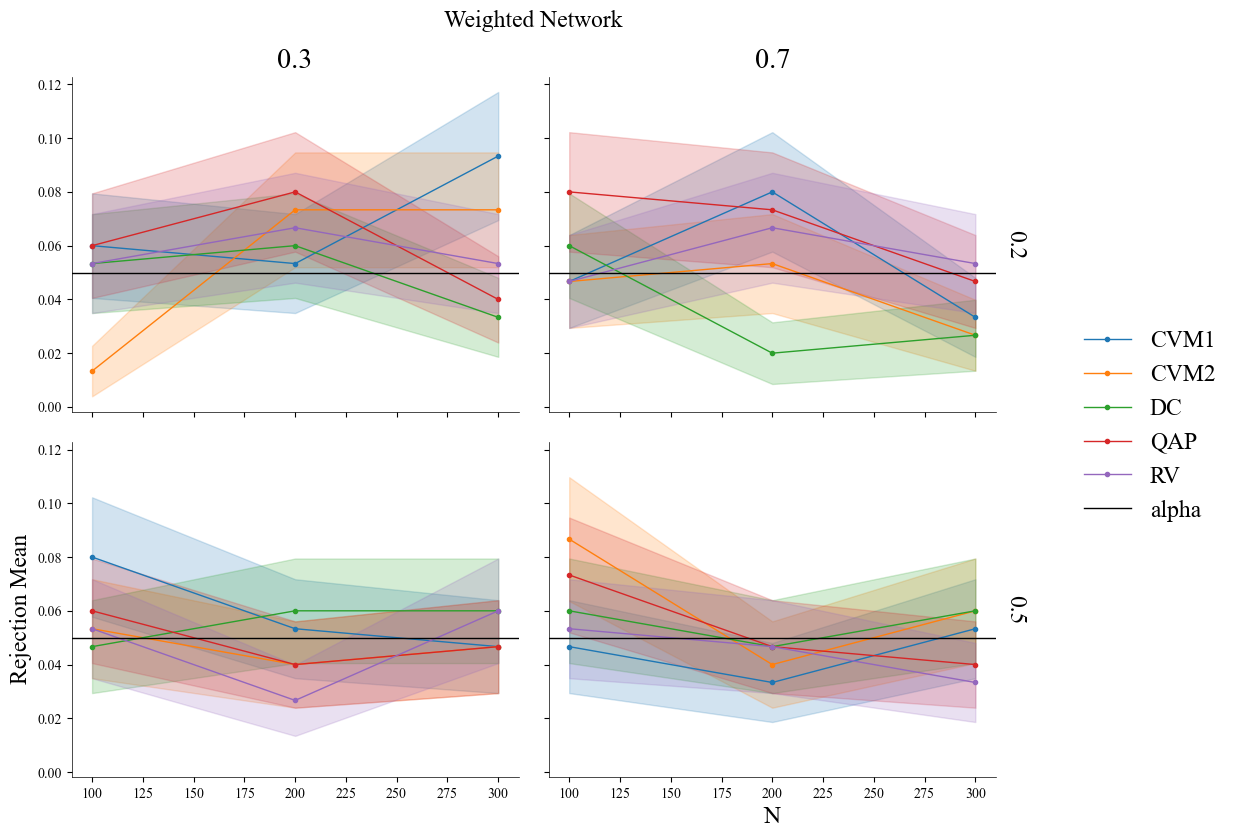

In [174]:
temp = agg_null_gaussian.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "sparsity_bias", "prob_switch"],
    height=4,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Weighted Network",
    hline=0.05,
    hline_name="alpha",
    show_col_names=False,
    show_row_names=False,
)

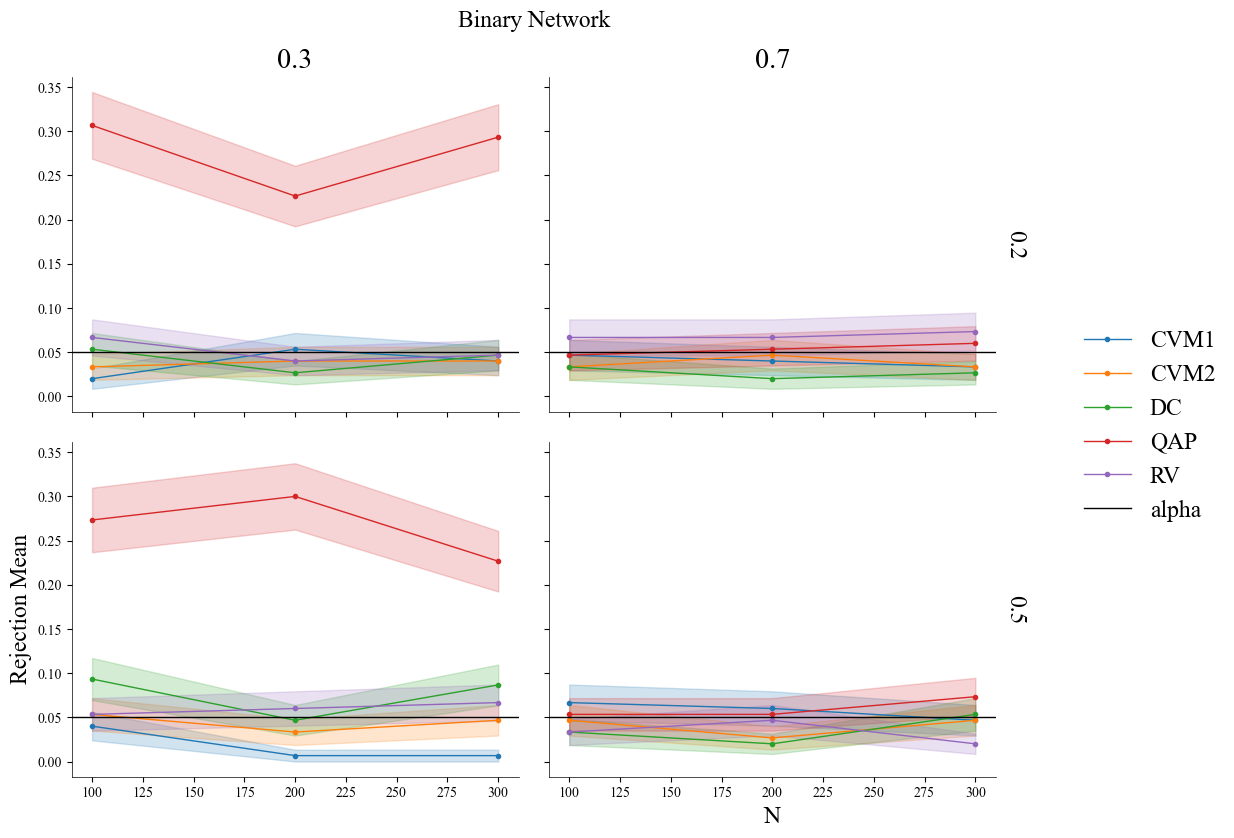

In [177]:
temp = agg_null_bernoulli.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "sparsity_bias", "prob_switch"],
    height=4,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="Binary Network",
    hline=0.05,
    hline_name="alpha",
    show_col_names=False,
    show_row_names=False,
)


flipping


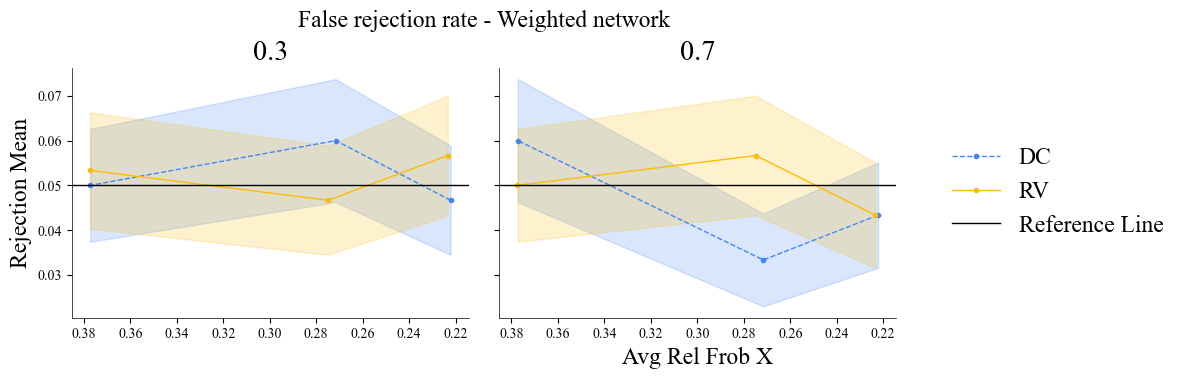

In [127]:
temp = agg_null_gaussian_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="Rejection_mean",
    factors=["method", "sparsity_bias"],
    height=3.5,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="False rejection rate - Weighted network",
    flip_x_axis=True,
    show_row_names=False,
    show_col_names=False,
    hline=0.05,
)

In [128]:
# temp = agg_null_gaussian_proc.copy()

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="avg_proc_dist_x",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals",],
#     height=3,
#     se_bands="FalseRejection_sem",
#     share_x=False,
#     share_y=False,
#     title="False rejection rate - Weighted network",
#     flip_x_axis=True,
# )

flipping


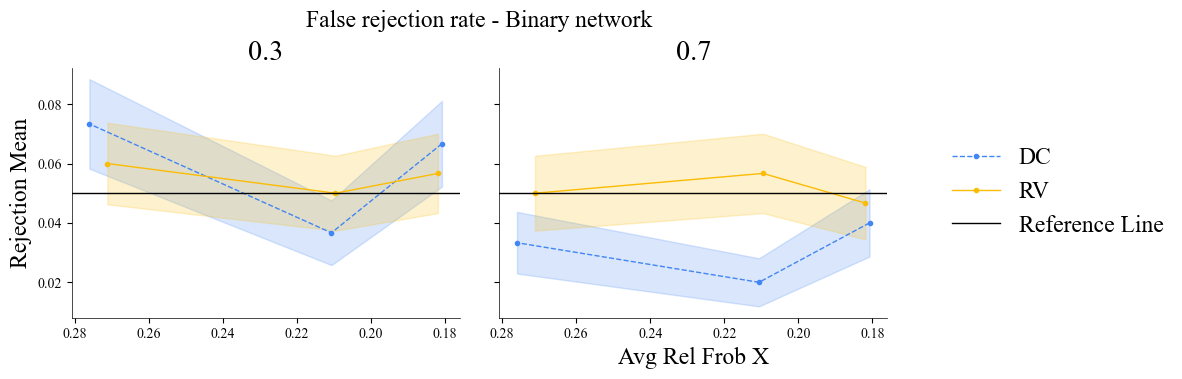

In [129]:
temp = agg_null_bernoulli_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="Rejection_mean",
    factors=["method", "sparsity_bias"],
    height=3.5,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=True,
    title="False rejection rate - Binary network",
    flip_x_axis=True,
    show_row_names=False,
    show_col_names=False,
    hline=0.05
)

### Power

In [184]:
agg_alt_gaussian = aggregate_results(
    results_alt_gaussian,
    y_axis="Rejection",
    x_axis="n",
    factors=["method", "assignment_mode", "block_probs_type", "sparsity_bias", "prob_switch"],
)

agg_alt_gaussian_frob = aggregate_results(
    results_alt_gaussian,
    y_axis="Rejection",
    x_axis="avg_rel_frob_x",
    factors=["block_probs_type", "method", "assignment_mode", "sparsity_bias", "prob_switch"]
)

agg_alt_gaussian_sparsity = aggregate_results(
    results_alt_gaussian,
    y_axis="density_A",
    x_axis="n",
    factors=["method", "assignment_mode", "block_probs_type", "sparsity_bias", "prob_switch"]
)

agg_alt_bernoulli = aggregate_results(
    results_alt_bernoulli,
    y_axis="Rejection",
    x_axis="n",
    factors=["method", "assignment_mode", "block_probs_type", "sparsity_bias", "prob_switch"],
)

agg_alt_bernoulli_frob = aggregate_results(
    results_alt_bernoulli,
    y_axis="Rejection",
    x_axis="avg_rel_frob_x",
    factors=["block_probs_type", "method", "assignment_mode", "sparsity_bias", "prob_switch"]
)

agg_alt_bernoulli_sparsity = aggregate_results(
    results_alt_bernoulli,
    y_axis="density_A",
    x_axis="n",
    factors=["method", "assignment_mode", "block_probs_type", "sparsity_bias", "prob_switch"]
)

In [191]:
agg_alt_bernoulli_sparsity['density_A_mean'].apply(lambda x: np.round(x, 1)).value_counts()

density_A_mean
0.1    90
0.6    90
Name: count, dtype: int64

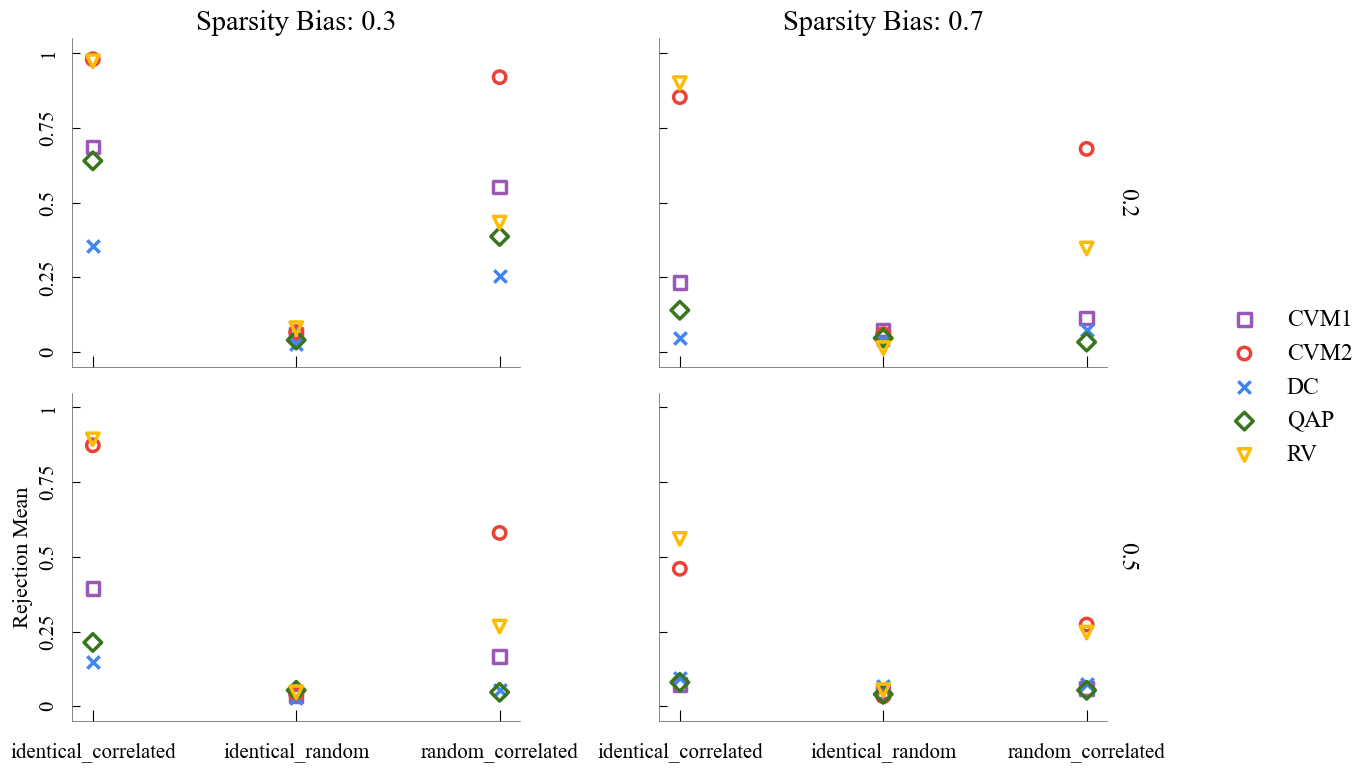

In [ ]:

temp = agg_alt_gaussian.copy()
temp = temp[temp['n']==300]
temp['setting'] = temp['block_probs_type'] + '_' + temp['assignment_mode']

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_scatter_markers,
    x_axis="setting",
    y_axis="Rejection_mean",
    factors=["method", "sparsity_bias", "prob_switch"],
    height=4,
    aspect=1.5,
    colors=colors,
    markers=marker_map, 
    add_legend=True,
    show_row_names=False,
    title="",
    show_x_axis_title=False,
    x_tick_labelsize=15,       
    y_tick_labelsize=15,       
    x_tick_rotation=0,
)


In [132]:
# heavy tails

# temp = agg_alt_02_gaussian.copy()
# temp = temp[temp['copula'].isin(['gumbel', 'clayton', 'gaussian'])]

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="Power_mean",
#     factors=["method", "marginals", "copula"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=True,
#     title="Weighted network - rho 0.2",
#     name_conversion={'n':'n (Number of nodes)', 'marginals':'', 'copula':''}
# )

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="Power_mean",
#     factors=["method", "copula", "marginals"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=True,
#     title="",
#     save_path="figures/power_weighted_02_heavy_tails"
# )

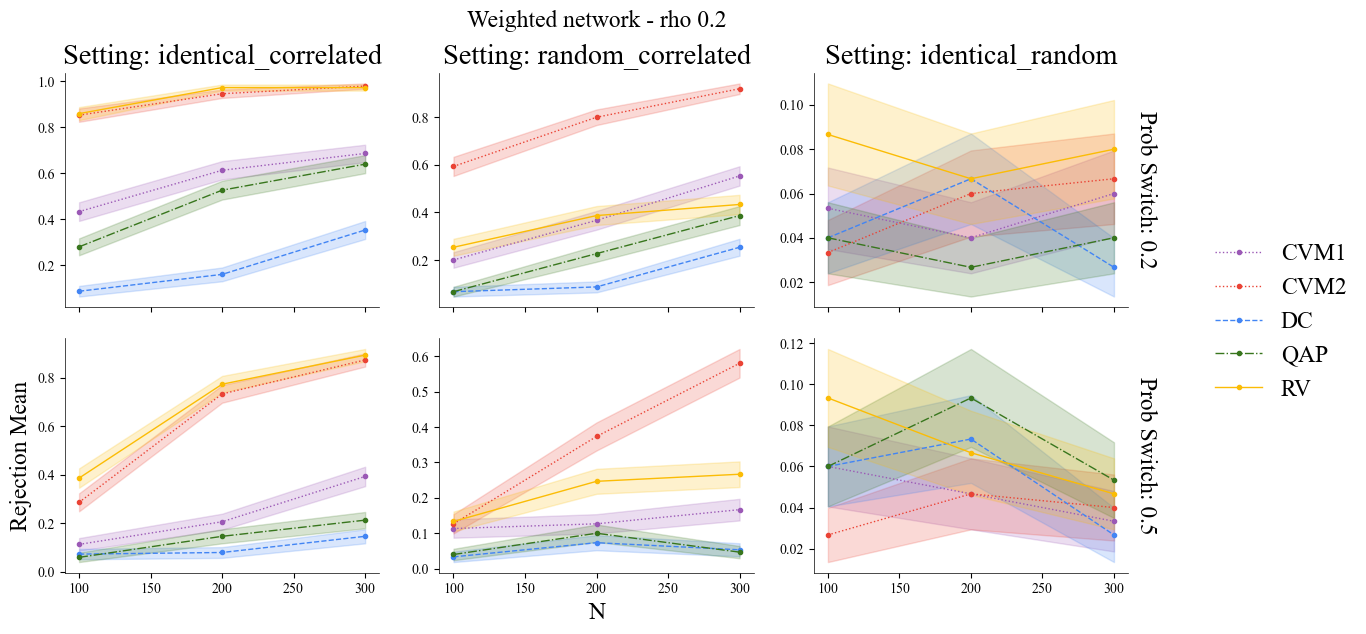

In [195]:
temp = agg_alt_gaussian.copy()
temp['setting'] = temp['block_probs_type'] + '_' + temp['assignment_mode']
temp = temp[temp['sparsity_bias']=='0.3']

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "setting", "prob_switch", "sparsity_bias"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
)

flipping


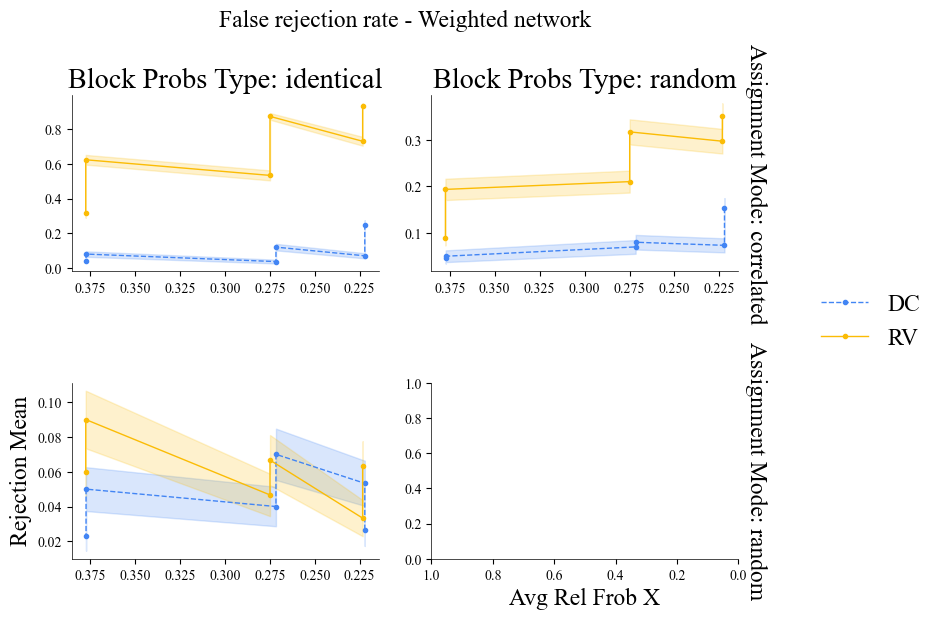

In [134]:
temp = agg_alt_gaussian_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="Rejection_mean",
    factors=["method", "block_probs_type","assignment_mode"],
    height=3,
    se_bands="Rejection_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Weighted network",
    flip_x_axis=True,
)

### Binary network

In [135]:
agg_density_bernoulli_alt = aggregate_results(
    results_alt_bernoulli,
    y_axis="density_A",
    x_axis="n",
    factors=["method", "assignment_mode", "block_probs_type", "sparsity_bias"],
)
agg_density_bernoulli_null = aggregate_results(
    results_null_bernoulli,
    x_axis="n",
    y_axis="density_A",
    factors=["method", "assignment_mode", "block_probs_type", "sparsity_bias"],
)

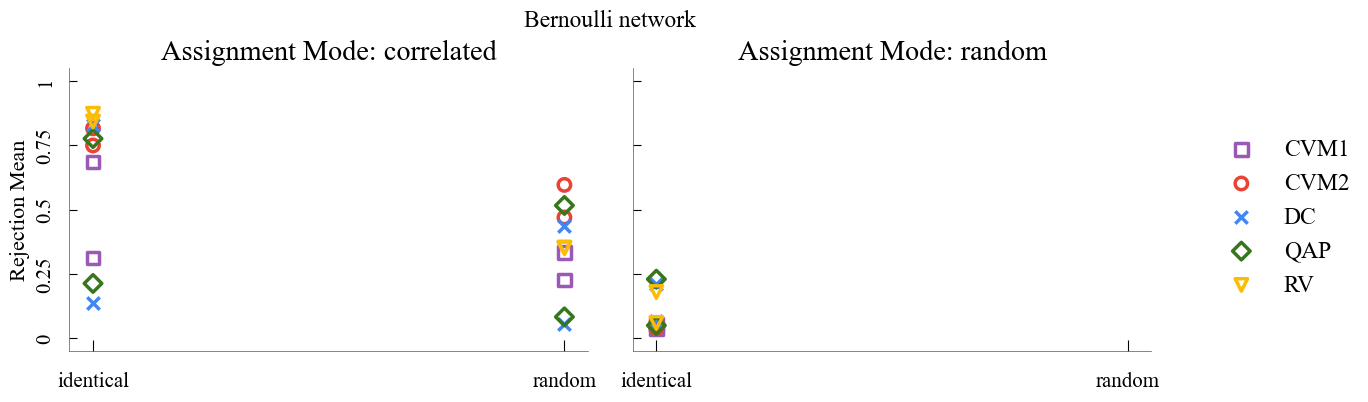

In [136]:
temp = agg_alt_bernoulli.copy()
temp = temp[temp['n']==300]

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_scatter_markers,
    x_axis="block_probs_type",
    y_axis="Rejection_mean",
    factors=["method", 'assignment_mode'],
    height=4,
    aspect=1.5,
    colors=colors,
    markers=marker_map, 
    add_legend=True,
    show_row_names=False,
    title="Bernoulli network",
    show_x_axis_title=False,
    x_tick_labelsize=15,       # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,       # ← same for y (optional)
    x_tick_rotation=0,
)



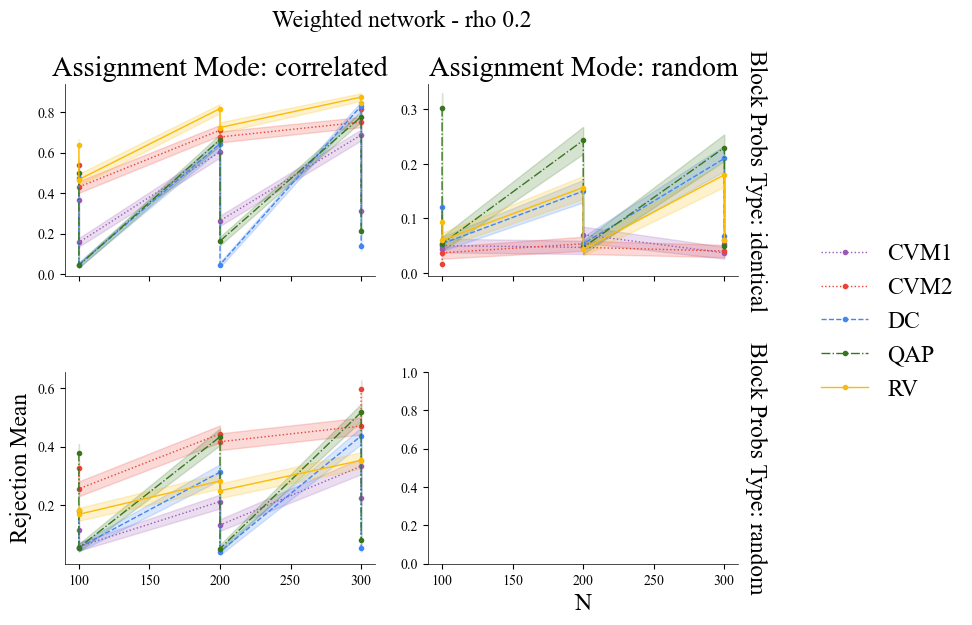

In [137]:
temp = agg_alt_bernoulli.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Rejection_mean",
    factors=["method", "assignment_mode", "block_probs_type"],
    height=3,
    se_bands="Rejection_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
)

flipping


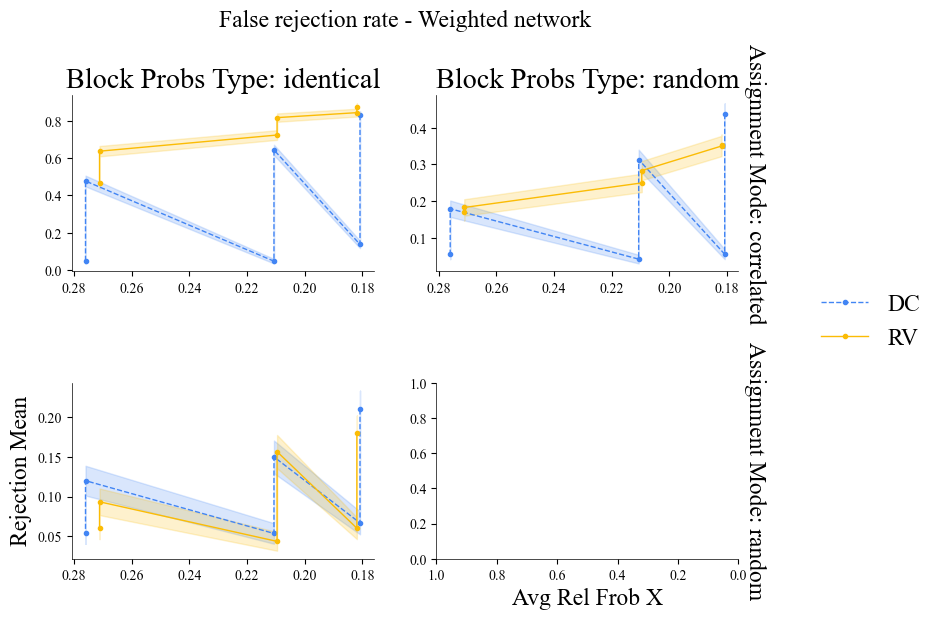

In [138]:
temp = agg_alt_bernoulli_frob.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="Rejection_mean",
    factors=["method", "block_probs_type","assignment_mode"],
    height=3,
    se_bands="Rejection_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Weighted network",
    flip_x_axis=True,
)